In [60]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
from sklearn.model_selection import train_test_split
%matplotlib inline

In [61]:
words = open('names.txt', 'r').read().splitlines()

#The goals 

in the context of emma 
3 -> 1 
... -> e
..e -> m

In [62]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [63]:
block_size = 3 

def build_dataset(words):
    X, Y = [], []
    
    for w in words:
        
        context = [0] * block_size
        
        for ch in w + '.':
            ix = stoi[ch] # change from text to int 
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] 
        
    X = torch.tensor(X)
        
    Y = torch.tensor(Y)
         
    # X_train,X_other = train_test_split(X, train_size=0.8, random_state=42)  
    # X_dev,X_test= train_test_split(X_other, train_size=0.5, random_state=42) 
    
    # Y_train,Y_other = train_test_split(Y, train_size=0.8, random_state=42)  
    # Y_dev,Y_test= train_test_split(Y_other, train_size=0.5, random_state=42) 
    
    # problem x ->! y 
    
    X_train, X_other, Y_train, Y_other = train_test_split(X,Y, train_size=0.8, random_state=42)
    X_dev, X_test, Y_dev, Y_test = train_test_split(X_other, Y_other, train_size=0.5, random_state=42)
    
    return X_train, Y_train, X_dev, Y_dev, X_test, Y_test,X,Y


In [64]:
X_train, Y_train, X_dev, Y_dev, X_test, Y_test,X,Y = build_dataset(words)

X_train.shape

torch.Size([182516, 3])

In [65]:
g = torch.Generator().manual_seed(2147483647) 
C = torch.rand((27,10), generator=g) 
W1 = torch.rand((30,200), generator=g) 
b1 = torch.rand((200),generator=g) 
W2 = torch.rand((200,27), generator=g) 
b2 = torch.rand((27), generator=g)

parameters = [C,W1,b1,W2,b2] 

In [66]:
total_params = sum(p.nelement() for p in parameters) 
total_params

11897

In [67]:
for p in parameters:
    p.requires_grad = True

In [75]:
lre = torch.linspace(-3,0,1000) # -3 to 0 evenly spread interms 1000 digits 
print(lre.shape)
lrs = 10 ** lre # this allow lre ro be 10**-3 is 0.001

torch.Size([1000])


In [76]:
slre = lre[::100]
slre
r = lrs[::100]
r

tensor([0.0010, 0.0020, 0.0040, 0.0080, 0.0159, 0.0317, 0.0634, 0.1265, 0.2526,
        0.5043])

In [77]:
lri =[]
lossi = []
stepi = []

In [78]:
for i in range(100):
    
     
     
    emb = C[X_train]    
    h = torch.tanh(emb.view(emb.shape[0],30) @ W1 + b1  )
    logits = h @W2 + b2 
    loss = F.cross_entropy(logits, Y_train)
    
    for p in parameters:
        p.grad = None  
        
    loss.backward()
    
    for p in parameters:
        p.data += -0.01*(p.data)

    lr = 0.1 if i < 100000 else 0.01# keep tracking of the loop
    
    for p in parameters:
        p.data += -lr * p.grad
        
    stepi.append(i)
    lossi.append(loss.log10().item())
     

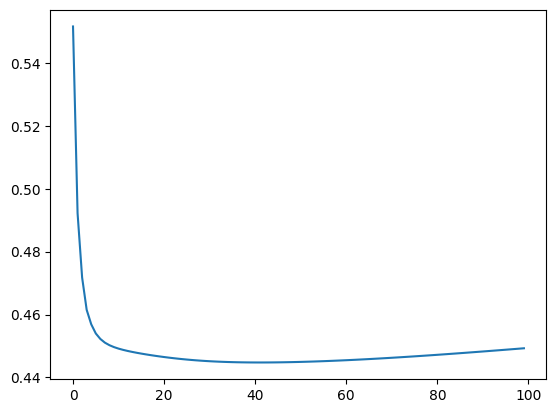

In [79]:
plt.plot(stepi, lossi)

In [80]:
# training loss 

emb = C[X_train]
h = torch.tanh(emb.view(emb.shape[0],30) @ W1 + b1  )
logits = h @W2 + b2 
loss = F.cross_entropy(logits, Y_train)
loss

tensor(2.8144, grad_fn=<NllLossBackward0>)

In [81]:
emb = C[X_dev]
h = torch.tanh(emb.view(emb.shape[0],30) @ W1 + b1 )
logits = h@W2 + b2
loss = F.cross_entropy(logits,Y_dev)
loss

tensor(2.8158, grad_fn=<NllLossBackward0>)

In [82]:
emb = C[X_test]
h = torch.tanh(emb.view(emb.shape[0],30) @ W1 + b1 )
logits = h@W2 + b2
loss = F.cross_entropy(logits,Y_dev)
loss

tensor(2.8857, grad_fn=<NllLossBackward0>)

In [83]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carpahxqae.
hqvihkimrsxrthty.
hncassnejrzhnenfapesyhc.
igqei.
ne.
mnia.
cmziiv.
yslein.
hh.
m.
.
oin.
qdijn.
srlilea.
vvdbq.
wqje.
ogijaryxixfk.
eupiurai.
ed.
eciia.
